# Notebook 9 – Data Transformation

This notebook applies distribution-shaping transformations to skewed numeric columns in `customer_transactions_raw.csv` and compares the distribution before and after each transformation, both numerically (skewness) and visually (histograms).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv('customer_transactions_raw.csv')
df['purchase_amount_clean'] = df['purchase_amount'].astype(str).str.replace('$', '', regex=False)
df['purchase_amount_clean'] = pd.to_numeric(df['purchase_amount_clean'], errors='coerce')
df_income = df.loc[(df['annual_income'] >= 0) & (df['annual_income'] < 900000000), 'annual_income'].dropna()
df_purchase = df.loc[df['purchase_amount_clean'] >= 0, 'purchase_amount_clean'].dropna()
print('income skewness:', df_income.skew())
print('purchase skewness:', df_purchase.skew())

income skewness: 29.922831877300503
purchase skewness: 14.495905900630365


## 1. Why Transform Data?

Many real-world numeric features, like `annual_income` and `purchase_amount` here, are **right-skewed**: most values cluster at the low end with a long tail of large values. This violates the assumptions of algorithms that expect roughly normal, symmetric input (linear regression, logistic regression, LDA) and can make patterns in the bulk of the data hard to see in visualizations. Transformations reshape the distribution to be more symmetric, stabilize variance, and make relationships more linear, without discarding any data points (unlike removing outliers).

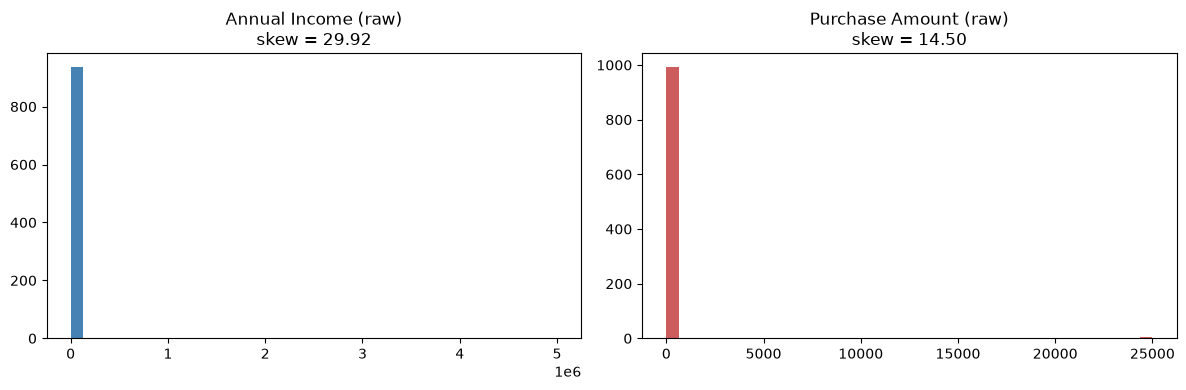

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_income, bins=40, color='steelblue')
axes[0].set_title(f'Annual Income (raw)\nskew = {df_income.skew():.2f}')
axes[1].hist(df_purchase, bins=40, color='indianred')
axes[1].set_title(f'Purchase Amount (raw)\nskew = {df_purchase.skew():.2f}')
plt.tight_layout()
plt.show()

## 2. Log Transformation

The log transform (`log(x)` or `log1p(x)` to safely handle zeros) compresses large values much more than small values, which pulls in a long right tail and reduces skewness. It only works on positive values.

**When to use:** strictly positive, heavily right-skewed data such as income, price, or population counts.

log-transformed skewness: 0.2603314617419356


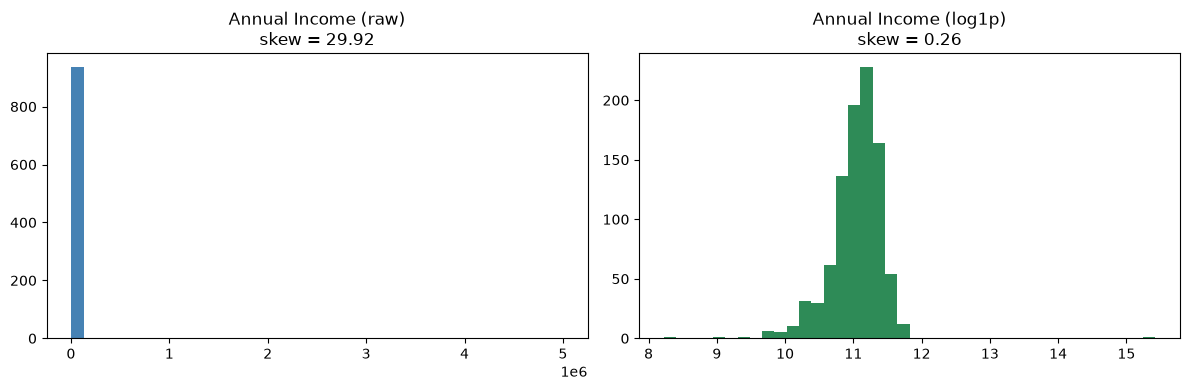

In [3]:
log_income = np.log1p(df_income)
print('log-transformed skewness:', log_income.skew())
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_income, bins=40, color='steelblue')
axes[0].set_title(f'Annual Income (raw)\nskew = {df_income.skew():.2f}')
axes[1].hist(log_income, bins=40, color='seagreen')
axes[1].set_title(f'Annual Income (log1p)\nskew = {log_income.skew():.2f}')
plt.tight_layout()
plt.show()

## 3. Square Root Transformation

The square root transform (`sqrt(x)`) also compresses large values, but less aggressively than the log transform. It works on non-negative values (zero is fine, unlike plain log).

**When to use:** moderately (not extremely) right-skewed data, or count data such as `quantity`, where a lighter compression than log is enough.

sqrt-transformed skewness: 11.74395453749566


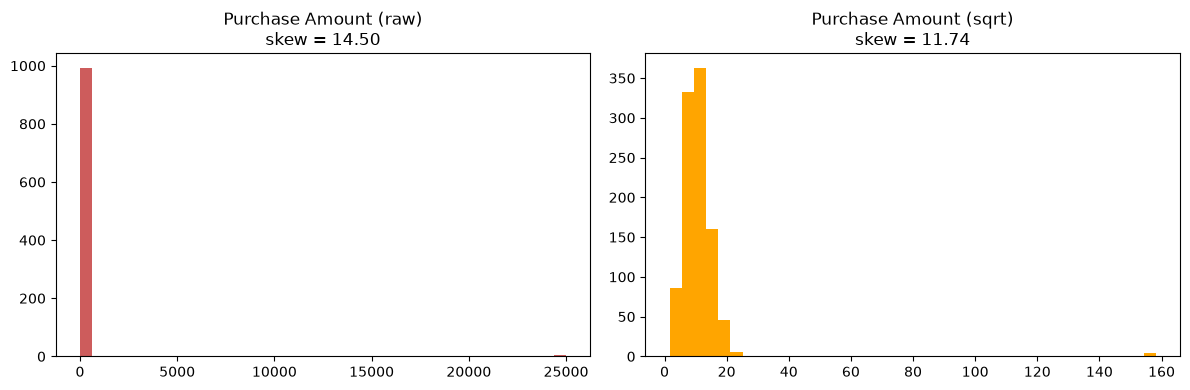

In [4]:
sqrt_purchase = np.sqrt(df_purchase)
print('sqrt-transformed skewness:', sqrt_purchase.skew())
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_purchase, bins=40, color='indianred')
axes[0].set_title(f'Purchase Amount (raw)\nskew = {df_purchase.skew():.2f}')
axes[1].hist(sqrt_purchase, bins=40, color='orange')
axes[1].set_title(f'Purchase Amount (sqrt)\nskew = {sqrt_purchase.skew():.2f}')
plt.tight_layout()
plt.show()

## 4. Power Transformation

A power transform raises each value to some exponent (e.g. `x**0.5`, `x**0.3`, `x**2`). Exponents less than 1 compress large values and reduce right skew; exponents greater than 1 do the opposite and can correct left skew. Log and square root are both special cases of this broader family.

**When to use:** when you want finer control over how aggressively the tail is compressed than log or sqrt individually provide.

power (0.3) transformed skewness: 8.320873441335094


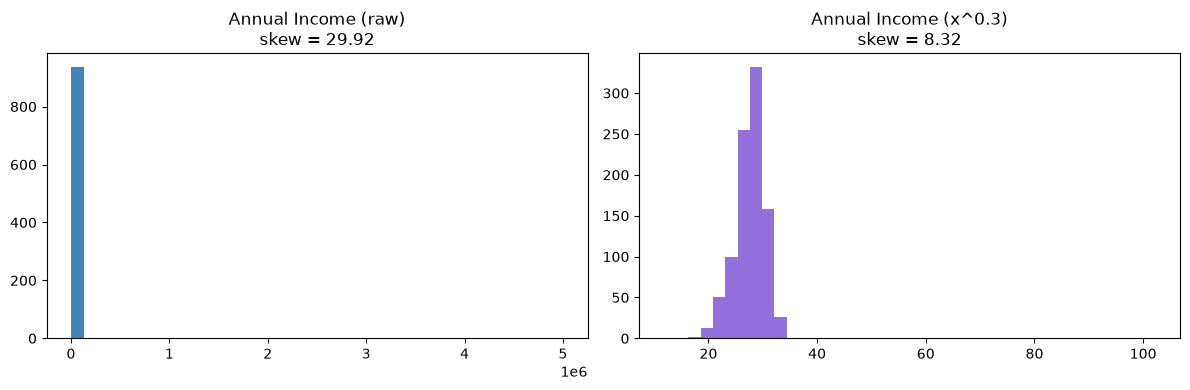

In [5]:
power_income_03 = df_income ** 0.3
print('power (0.3) transformed skewness:', power_income_03.skew())
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_income, bins=40, color='steelblue')
axes[0].set_title(f'Annual Income (raw)\nskew = {df_income.skew():.2f}')
axes[1].hist(power_income_03, bins=40, color='mediumpurple')
axes[1].set_title(f'Annual Income (x^0.3)\nskew = {power_income_03.skew():.2f}')
plt.tight_layout()
plt.show()

## 5. Box-Cox Transformation

Box-Cox automatically searches for the optimal power-transform parameter (lambda) that makes the data as close to normally distributed as possible. It is a more principled version of manually picking a power like log or sqrt.

**Restriction:** Box-Cox requires strictly **positive** values (no zero or negative numbers), which is why `scipy`/`sklearn` will raise an error if applied to data containing zero or negative values.

**When to use:** strictly positive skewed data where you want the best-fitting power transform rather than guessing an exponent.

optimal lambda: -0.025533048549302866
box-cox transformed skewness: -0.062061454808201286


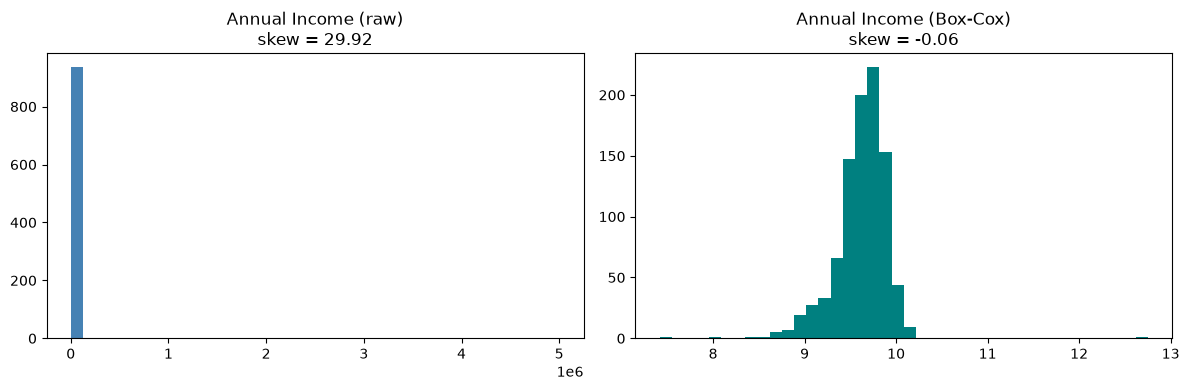

In [6]:
from scipy.stats import boxcox
boxcox_income, best_lambda = boxcox(df_income)
print('optimal lambda:', best_lambda)
print('box-cox transformed skewness:', pd.Series(boxcox_income).skew())
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_income, bins=40, color='steelblue')
axes[0].set_title(f'Annual Income (raw)\nskew = {df_income.skew():.2f}')
axes[1].hist(boxcox_income, bins=40, color='teal')
axes[1].set_title(f'Annual Income (Box-Cox)\nskew = {pd.Series(boxcox_income).skew():.2f}')
plt.tight_layout()
plt.show()

## 6. Yeo-Johnson Transformation

Yeo-Johnson is a generalization of Box-Cox that works on **zero and negative values as well as positive ones**, making it more broadly applicable when a column might contain values that Box-Cox can't handle.

**When to use:** skewed data that includes zero or negative values, or as a safer general-purpose default when you're not sure whether Box-Cox's positivity requirement will always hold (e.g. after future data updates introduce a zero).

yeo-johnson transformed skewness: -0.11271879888951927


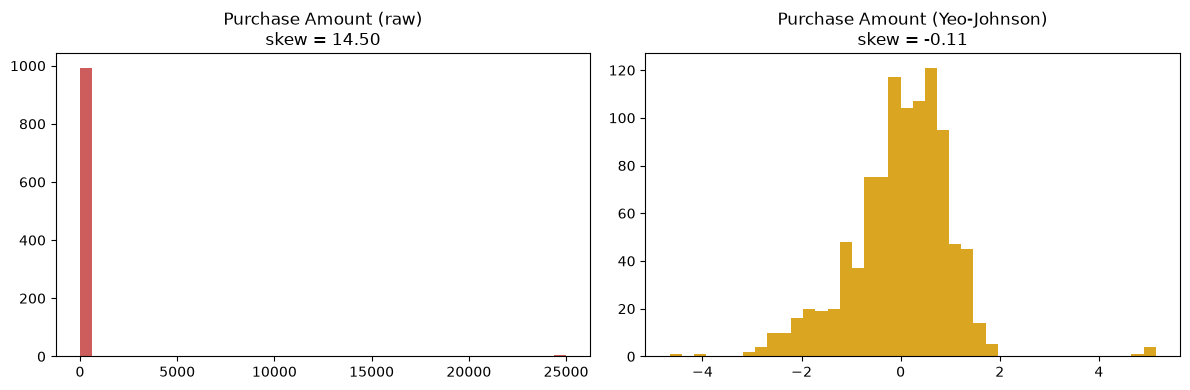

In [7]:
from sklearn.preprocessing import PowerTransformer
yeo_transformer = PowerTransformer(method='yeo-johnson')
purchase_reshaped = df_purchase.values.reshape(-1, 1)
yeo_purchase = yeo_transformer.fit_transform(purchase_reshaped).flatten()
print('yeo-johnson transformed skewness:', pd.Series(yeo_purchase).skew())
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_purchase, bins=40, color='indianred')
axes[0].set_title(f'Purchase Amount (raw)\nskew = {df_purchase.skew():.2f}')
axes[1].hist(yeo_purchase, bins=40, color='goldenrod')
axes[1].set_title(f'Purchase Amount (Yeo-Johnson)\nskew = {pd.Series(yeo_purchase).skew():.2f}')
plt.tight_layout()
plt.show()

## 7. Handling Skewed Data — Putting It Together

A practical workflow for a skewed column:

1. Check skewness (e.g. `series.skew()`); a value near 0 is roughly symmetric, and values beyond about ±1 indicate notable skew.
2. Confirm whether the skew reflects genuine variation or leftover data errors (Notebook 6) — transformation is not a substitute for outlier/error handling.
3. Choose a transform based on the data's sign: log/sqrt/Box-Cox for strictly positive data, Yeo-Johnson for data that may include zero/negative values.
4. Re-check skewness and visually compare histograms after transforming, as done throughout this notebook, to confirm the transform actually helped.

In [8]:
skew_summary = pd.DataFrame({
    'transformation': ['raw', 'log1p', 'sqrt', 'power (x^0.3)', 'box-cox', 'yeo-johnson'],
    'income_skew': [df_income.skew(), log_income.skew(), np.nan, power_income_03.skew(), pd.Series(boxcox_income).skew(), np.nan],
    'purchase_skew': [df_purchase.skew(), np.nan, sqrt_purchase.skew(), np.nan, np.nan, pd.Series(yeo_purchase).skew()],
})
skew_summary

,transformation,income_skew,purchase_skew
0,raw,29.922832,14.495906
1,log1p,0.260331,NaN
2,sqrt,NaN,11.743955
3,power (x^0.3),8.320873,NaN
4,box-cox,-0.062061,NaN
5,yeo-johnson,NaN,-0.112719


## 8. Normalization

In the context of this pipeline, normalization (Min-Max scaling, covered in depth in Notebook 8) rescales a column into a fixed range such as [0, 1]. It is often applied **after** a skew-reducing transformation like log or Box-Cox, since normalization alone does not change a distribution's shape — it only rescales it.

In [9]:
from sklearn.preprocessing import MinMaxScaler
log_income_normalized = MinMaxScaler().fit_transform(log_income.values.reshape(-1, 1)).flatten()
pd.Series(log_income_normalized).describe()

count    938.000000
mean       0.391659
std        0.053999
min        0.000000
25%        0.367232
50%        0.398919
75%        0.424223
max        1.000000
dtype: float64

## 9. Standardization

Standardization (Z-score scaling, also covered in Notebook 8) centers a column at mean 0 with standard deviation 1. Like normalization, it does not fix skewness by itself — applying it to the already log-transformed income gives a symmetric, unit-scale feature ready for a linear model.

In [10]:
from sklearn.preprocessing import StandardScaler
log_income_standardized = StandardScaler().fit_transform(log_income.values.reshape(-1, 1)).flatten()
pd.Series(log_income_standardized).describe()

count    9.380000e+02
mean     1.528273e-15
std      1.000533e+00
min     -7.256901e+00
25%     -4.525915e-01
50%      1.345184e-01
75%      6.033640e-01
max      1.127173e+01
dtype: float64

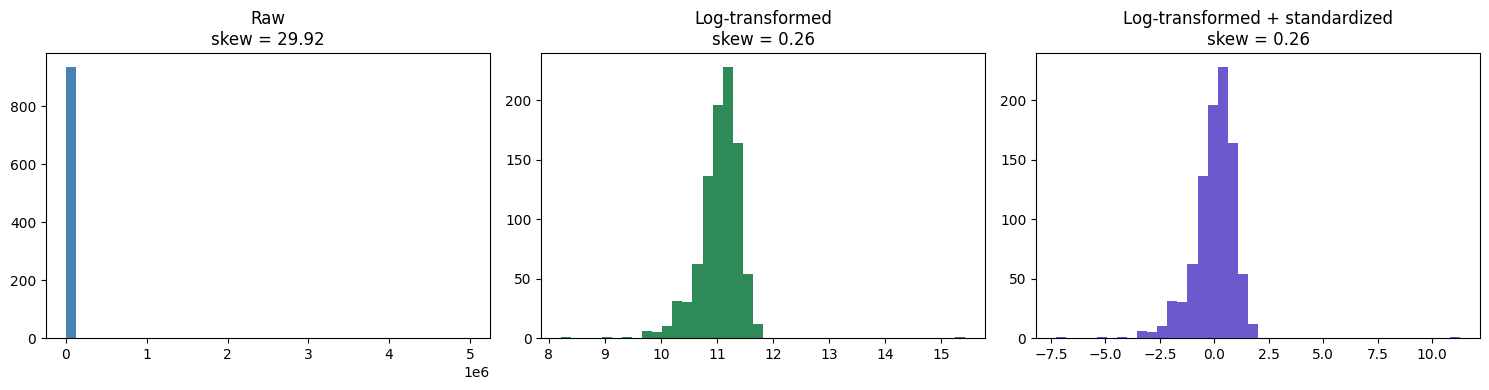

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(df_income, bins=40, color='steelblue')
axes[0].set_title(f'Raw\nskew = {df_income.skew():.2f}')
axes[1].hist(log_income, bins=40, color='seagreen')
axes[1].set_title(f'Log-transformed\nskew = {log_income.skew():.2f}')
axes[2].hist(log_income_standardized, bins=40, color='slateblue')
axes[2].set_title(f'Log-transformed + standardized\nskew = {pd.Series(log_income_standardized).skew():.2f}')
plt.tight_layout()
plt.show()

## 10. Summary

- `annual_income` and `purchase_amount_clean` are both heavily right-skewed (skewness far above 1).
- Log, square root, and power transforms all reduce skewness noticeably; Box-Cox and Yeo-Johnson search for the best-fitting exponent automatically and generally produced the most symmetric result among the positive-only methods.
- Yeo-Johnson is the safer general default when a column might later include zero or negative values.
- Normalization and standardization reshape the *scale*, not the *shape*, of a distribution — they are complementary steps that typically follow a skew-reducing transformation, not a replacement for one.

In [12]:
df.to_csv('customer_transactions_transformed.csv', index=False)
df.shape

(1000, 13)